In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.curve_model.pca_curve_model import PCAYieldCurveModel

In [2]:
# loading yield curves
df = pd.read_csv(
    "../data/processed/cleaned_yield_curve_fred.csv",
    index_col = 'date',
    parse_dates = True
)

# initialize PCA model
pca_model = PCAYieldCurveModel(n_components = 3)

# fit PCA
factor_history = pca_model.fit(df_rates = df)
print(f'Factor History shape: {factor_history.shape}')
print(f'Expalined variance by PCA model: {pca_model.explained_variance()}')

Factor History shape: (6841, 3)
Expalined variance by PCA model: [0.82297491 0.12597488 0.03172446]


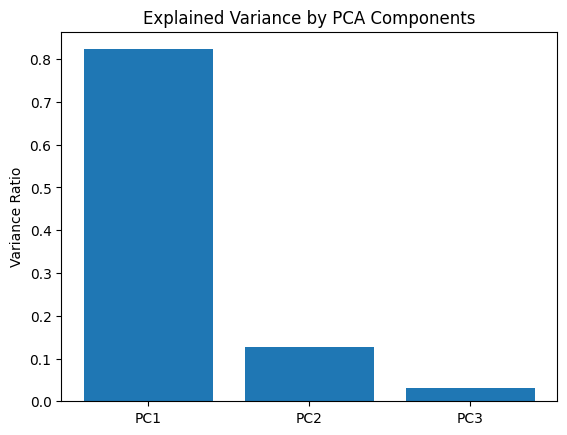

In [3]:
# ploting explained variance of the PCA model
var = pca_model.explained_variance()

plt.bar(['PC1', 'PC2', 'PC3'], var)
plt.title('Explained Variance by PCA Components')
plt.ylabel('Variance Ratio')
plt.show()

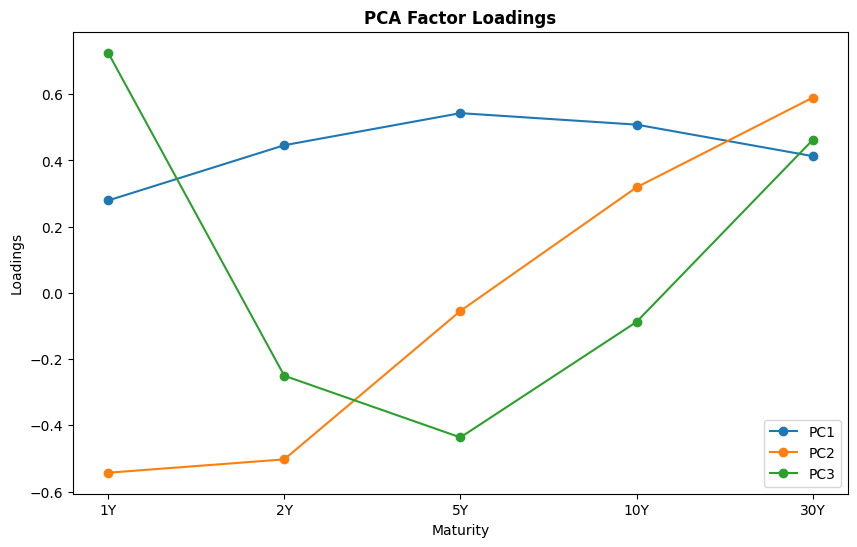

In [4]:
# ploting factor loadings
loadings = pca_model.loadings
maturities = list(df.columns)

plt.figure(figsize=(10, 6))

for i in range(3):
    plt.plot(
        maturities, 
        loadings[i], 
        marker = 'o',
        label = f"PC{i+1}"
    )

plt.legend()
plt.title('PCA Factor Loadings', fontweight = 'bold')
plt.xlabel('Maturity')
plt.ylabel('Loadings')
plt.show()

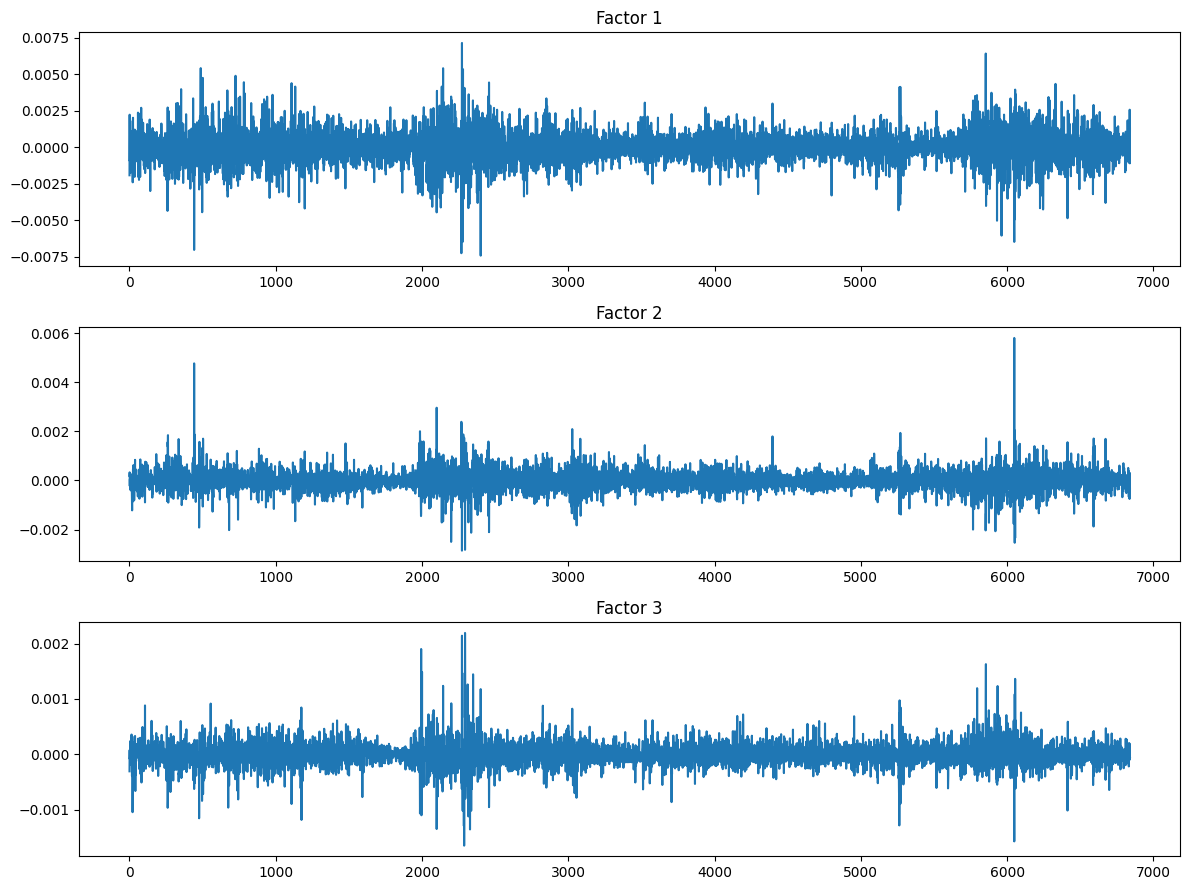

In [5]:
# ploting factor time series
fig, axes = plt.subplots(3, 1, figsize=(12, 9))

for i in range(3):
    axes[i].plot(factor_history[:, i])
    axes[i].set_title(f"Factor {i+1}")

plt.tight_layout()
plt.show()

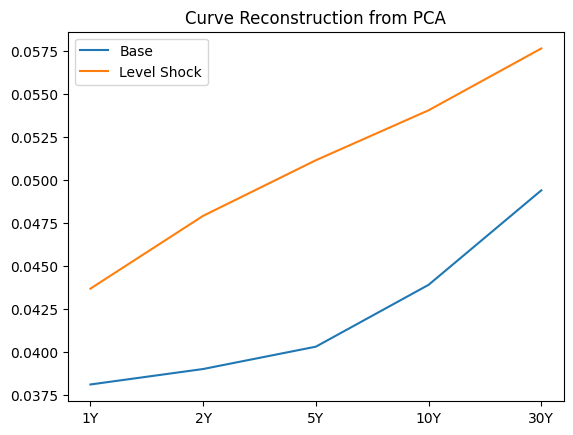

In [6]:
### reconstructing shocked curve
# extracting last yield curve
yield_matrix = df.values
last_curve = yield_matrix[-1]

# random factor shock
random_factors = np.array([[1, 0, 0]]) * 0.02

# converting factors into curve change
dy = pca_model.inverse_transform(random_factors)

# reconstructing shocked curve
shocked_curve = last_curve + dy[0]

plt.plot(df.columns, last_curve, label = 'Base')
plt.plot(df.columns, shocked_curve, label = 'Level Shock')
plt.legend()
plt.title('Curve Reconstruction from PCA')
plt.show()